SECTION 3: RADIAL METALLICITY RELATIONS

Columns in FITS file:
['x', 'y', 'z', 'A_O']

Columns used:
x position : x
y position : y
z position : z
A(O)       : A_O

Number of valid gas particles: 511520
Radial range: 0.032 to 24.998 kpc
A(O) range: 7.684 to 9.253

QUESTION 2: LINEAR FIT
Intercept = 9.127839 ± 0.000232 dex
Slope     = -0.034196 ± 0.000015 dex/kpc

Fitting method:
scipy.stats.linregress ordinary least-squares linear regression
Fit hyperparameters:
No tunable fitting hyperparameters were used.
No sigma clipping was applied; all valid particles were fitted.


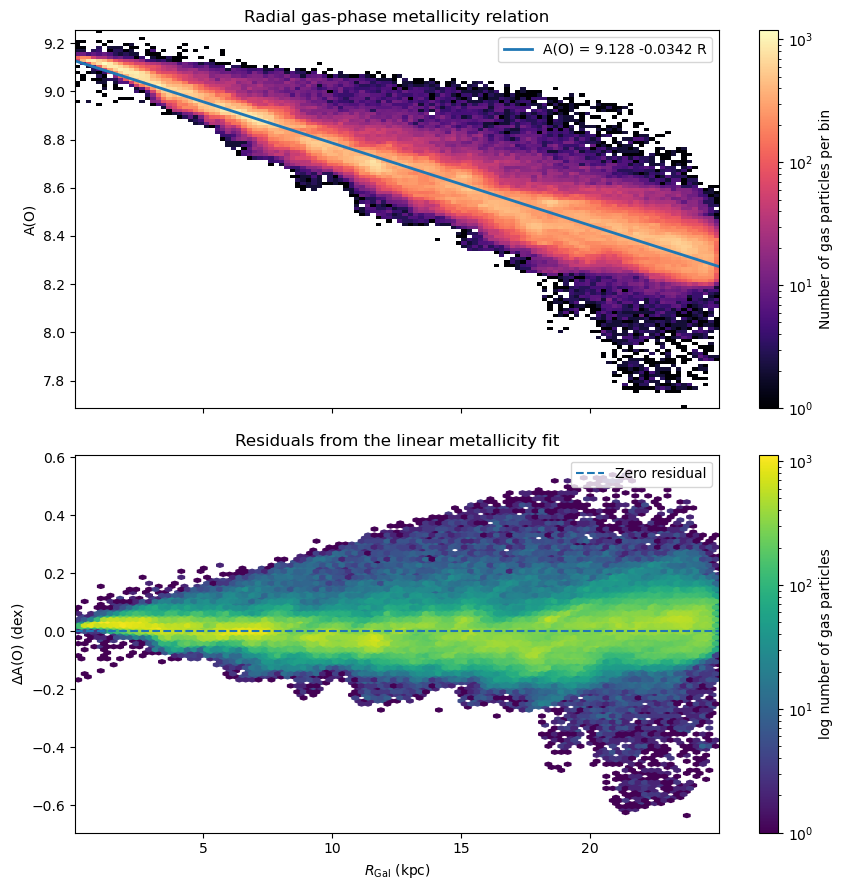


QUESTION 1 RESULT
Two-panel radial figure saved to: figures/section3_radial_metallicity_relation.png

QUESTION 3: MODEL PERFORMANCE
Overall RMSE              = 0.07265 dex
Overall MAE               = 0.05173 dex
Residual standard dev.    = 0.07265 dex
R-squared                 = 0.91254

Performance in radial bins:
 R_min_kpc  R_max_kpc     N  RMSE_dex  MAE_dex  Median_residual_dex
   0.00000    2.50000 23576   0.02948  0.02617              0.02523
   2.50000    5.00000 42011   0.03373  0.02592              0.01295
   5.00000    7.50000 49544   0.03945  0.02746              0.00136
   7.50000   10.00000 44702   0.05642  0.04161             -0.01082
  10.00000   12.50000 50219   0.06407  0.04754             -0.02282
  12.50000   15.00000 50004   0.07622  0.05667             -0.01051
  15.00000   17.50000 55607   0.08353  0.06156             -0.02525
  17.50000   20.00000 66475   0.09146  0.07026             -0.02414
  20.00000   22.50000 63317   0.09053  0.06482              0.01437
  

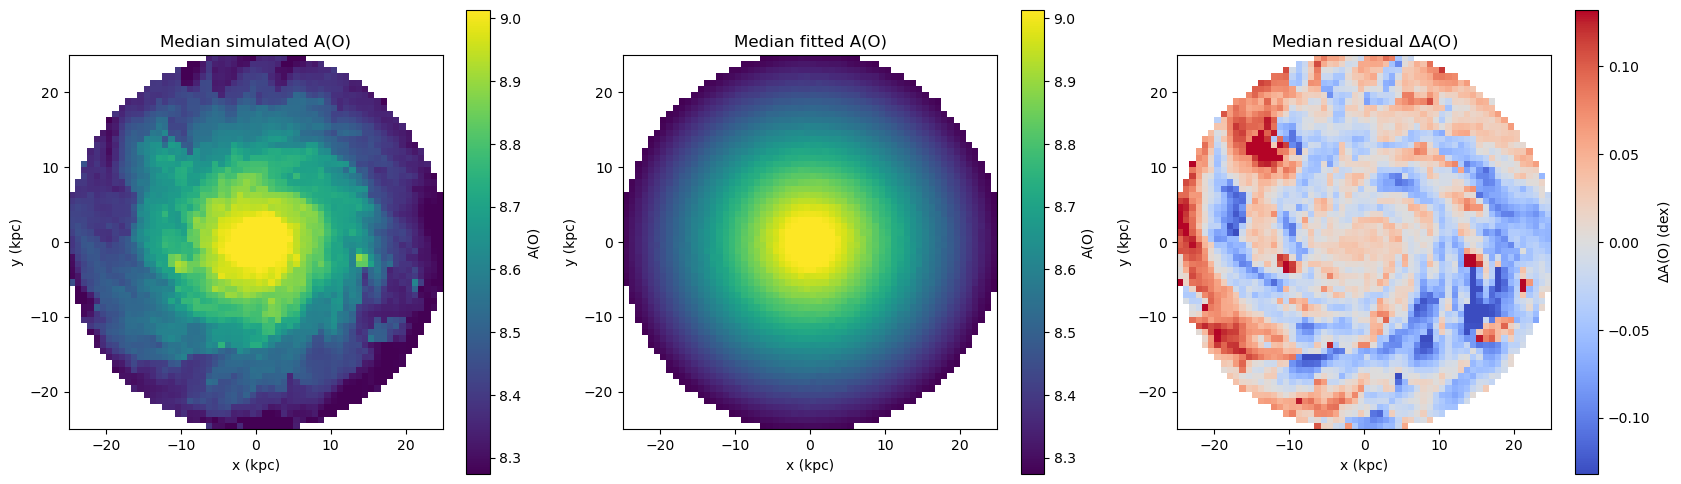


QUESTION 4 RESULT
Three-panel x-y figure saved to: figures/section3_xy_metallicity_maps.png

QUESTION 5: BINNING CHOICE
Number of bins per axis: 60
Spatial bin width: 0.833 kpc
Median particles per populated bin: 116.0
Fraction of spatial bins with no particles: 19.2%

Binning discussion:
I used 60 x 60 bins, corresponding to approximately 0.83 kpc per spatial bin. This provides enough spatial resolution to reveal non-axisymmetric structure while retaining enough particles in most populated bins for a stable median.
Using fewer bins would smooth over smaller-scale metallicity structures and could hide coherent residual patterns.
Using substantially more bins would reduce the number of particles per bin, producing noisier medians and more empty or poorly sampled bins.

QUESTION 6: DETAILED RESIDUAL ANALYSIS
Azimuthal peak-to-peak median residual variation: 0.03788 dex
Most positive residual sector: 60-90 degrees
Most negative residual sector: 300-330 degrees


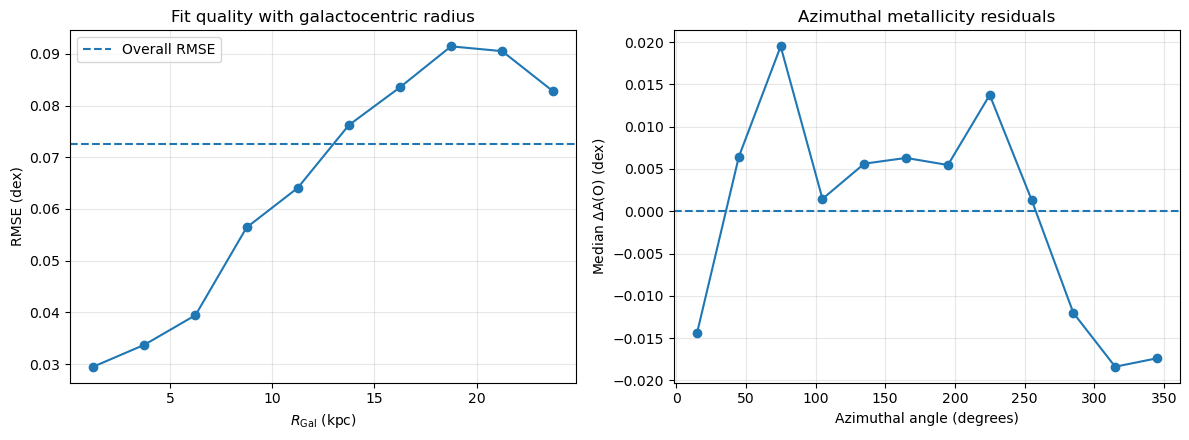


Residual diagnostic figure saved to: figures/section3_residual_diagnostics.png

Physical interpretation:
The linear model represents only an axisymmetric radial metallicity gradient. Coherent positive and negative residual regions in the x-y map therefore indicate metallicity structure that depends on position as well as radius.
A reasonable explanation is non-axisymmetric chemical structure associated with spiral arms, localised gas accretion, feedback-driven flows, or incomplete azimuthal mixing.These processes can create gas that is locally more metal-rich or metal-poor than predicted by a purely radial linear model.
The measured azimuthal variation and the change in RMSE with radius show quantitatively that a single straight line does not capture all of the spatial metallicity structure in the simulated galaxy.

SECTION 3 SUMMARY
Number of gas particles:          511520
Intercept:                        9.127839 ± 0.000232 dex
Slope:                            -0.034196 ± 0.000015

In [3]:
# SECTION 3: RADIAL METALLICITY RELATIONS IN SIMULATIONS

import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.table import Table
from scipy import stats
from scipy.stats import binned_statistic_2d
from matplotlib.colors import LogNorm


# SETUP AND DATA

# Input simulation file.
fits_path = (
    "data/"
    "nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits"
)

# Making sure the figures directory exists.
os.makedirs("figures", exist_ok=True)

# Reading the FITS table.
table = Table.read(fits_path)

print("=" * 70)
print("SECTION 3: RADIAL METALLICITY RELATIONS")
print("=" * 70)

print("\nColumns in FITS file:")
print(table.colnames)


# This makes the code tolerant of small differences in column names.
def normalise_name(name):
    return re.sub(r"[^a-zA-Z0-9]", "", str(name)).lower()


def find_column(candidates):
    """Finding the most likely FITS column from a list of names."""

    normalised = {
        normalise_name(name): name
        for name in table.colnames
    }

    # Trying exact matches.
    for candidate in candidates:
        key = normalise_name(candidate)
        if key in normalised:
            return normalised[key]

    # Then trying longer partial matches.
    for candidate in candidates:
        key = normalise_name(candidate)

        if len(key) >= 4:
            for column in table.colnames:
                if key in normalise_name(column):
                    return column

    raise KeyError(
        f"Could not identify column. Tried: {candidates}. "
        f"Available columns: {table.colnames}"
    )


# Identifying the x, y, z and oxygen-abundance columns.
x_col = find_column(
    ["x", "x_kpc", "xpos", "position_x"]
)

y_col = find_column(
    ["y", "y_kpc", "ypos", "position_y"]
)

z_col = find_column(
    ["z", "z_kpc", "zpos", "position_z"]
)

ao_col = find_column(
    [
        "oxygen_ao",
        "oxygenao",
        "A(O)",
        "AO",
        "oxygen_abundance",
        "metallicity"
    ]
)


print("\nColumns used:")
print(f"x position : {x_col}")
print(f"y position : {y_col}")
print(f"z position : {z_col}")
print(f"A(O)       : {ao_col}")


# Converting the FITS columns to normal NumPy arrays.
x = np.asarray(table[x_col], dtype=float)
y = np.asarray(table[y_col], dtype=float)
z = np.asarray(table[z_col], dtype=float)
ao = np.asarray(table[ao_col], dtype=float)


# Calculating cylindrical galactocentric radius.
r_gal = np.sqrt(x**2 + y**2)


# Keeping finite values within the required R_Gal < 25 kpc range.
valid = (
    np.isfinite(x)
    & np.isfinite(y)
    & np.isfinite(z)
    & np.isfinite(ao)
    & np.isfinite(r_gal)
    & (r_gal < 25.0)
)

x = x[valid]
y = y[valid]
z = z[valid]
ao = ao[valid]
r_gal = r_gal[valid]


print(f"\nNumber of valid gas particles: {len(ao)}")
print(
    f"Radial range: {r_gal.min():.3f} to "
    f"{r_gal.max():.3f} kpc"
)
print(
    f"A(O) range: {ao.min():.3f} to "
    f"{ao.max():.3f}"
)


# QUESTIONS 1 AND 2
# LINEAR RADIAL METALLICITY FIT

# Fitting A(O) = intercept + slope * R_Gal using ordinary least squares.
fit = stats.linregress(r_gal, ao)

slope = fit.slope
intercept = fit.intercept
slope_error = fit.stderr
intercept_error = fit.intercept_stderr


# Calculating metallicity predicted by the linear model.
ao_fit = intercept + slope * r_gal

# Residual = simulated metallicity - fitted metallicity.
residual = ao - ao_fit


print("\n" + "=" * 70)
print("QUESTION 2: LINEAR FIT")
print("=" * 70)

print(
    f"Intercept = {intercept:.6f} ± "
    f"{intercept_error:.6f} dex"
)

print(
    f"Slope     = {slope:.6f} ± "
    f"{slope_error:.6f} dex/kpc"
)

print("\nFitting method:")
print("scipy.stats.linregress ordinary least-squares linear regression")

print("Fit hyperparameters:")
print("No tunable fitting hyperparameters were used.")
print("No sigma clipping was applied; all valid particles were fitted.")


# QUESTION 1
# TWO-PANEL RADIAL METALLICITY FIGURE

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 9),
    sharex=True
)


# Panel (a): logarithmic density plot

density = axes[0].hist2d(
    r_gal,
    ao,
    bins=120,
    norm=LogNorm(),
    cmap="magma"
)

# Plotting the fitted linear relation.
r_line = np.linspace(
    r_gal.min(),
    r_gal.max(),
    500
)

ao_line = intercept + slope * r_line

axes[0].plot(
    r_line,
    ao_line,
    linewidth=2,
    label=(
        f"A(O) = {intercept:.3f} "
        f"{slope:+.4f} R"
    )
)

axes[0].set_ylabel("A(O)")
axes[0].set_title(
    "Radial gas-phase metallicity relation"
)
axes[0].legend()

cbar1 = fig.colorbar(
    density[3],
    ax=axes[0]
)

cbar1.set_label(
    "Number of gas particles per bin"
)


# Panel (b): residuals

residual_density = axes[1].hexbin(
    r_gal,
    residual,
    gridsize=100,
    bins="log",
    mincnt=1,
    cmap="viridis"
)

axes[1].axhline(
    0,
    linewidth=1.5,
    linestyle="--",
    label="Zero residual"
)

axes[1].set_xlabel(
    r"$R_{\rm Gal}$ (kpc)"
)

axes[1].set_ylabel(
    r"$\Delta$A(O) (dex)"
)

axes[1].set_title(
    "Residuals from the linear metallicity fit"
)

axes[1].legend()

cbar2 = fig.colorbar(
    residual_density,
    ax=axes[1]
)

cbar2.set_label(
    "log number of gas particles"
)


plt.tight_layout()

radial_figure = (
    "figures/"
    "section3_radial_metallicity_relation.png"
)

plt.savefig(
    radial_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\n" + "=" * 70)
print("QUESTION 1 RESULT")
print("=" * 70)

print(
    f"Two-panel radial figure saved to: "
    f"{radial_figure}"
)


# QUESTION 3
# QUANTITATIVE GOODNESS OF FIT

# Overall fit statistics.
rmse = np.sqrt(
    np.mean(residual**2)
)

mae = np.mean(
    np.abs(residual)
)

residual_std = np.std(
    residual,
    ddof=1
)

ss_res = np.sum(
    residual**2
)

ss_tot = np.sum(
    (ao - np.mean(ao))**2
)

r_squared = (
    1.0 - ss_res / ss_tot
)


print("\n" + "=" * 70)
print("QUESTION 3: MODEL PERFORMANCE")
print("=" * 70)

print(f"Overall RMSE              = {rmse:.5f} dex")
print(f"Overall MAE               = {mae:.5f} dex")
print(f"Residual standard dev.    = {residual_std:.5f} dex")
print(f"R-squared                 = {r_squared:.5f}")


# Examining model performance in radial bins.
n_radial_bins = 10

radial_edges = np.linspace(
    0,
    25,
    n_radial_bins + 1
)

radial_centres = 0.5 * (
    radial_edges[:-1]
    + radial_edges[1:]
)

radial_bin_number = np.digitize(
    r_gal,
    radial_edges
) - 1


radial_results = []

for i in range(n_radial_bins):

    in_bin = radial_bin_number == i
    n_bin = np.sum(in_bin)

    if n_bin > 0:

        bin_rmse = np.sqrt(
            np.mean(
                residual[in_bin]**2
            )
        )

        bin_mae = np.mean(
            np.abs(
                residual[in_bin]
            )
        )

        bin_median = np.median(
            residual[in_bin]
        )

        radial_results.append(
            {
                "R_min_kpc": radial_edges[i],
                "R_max_kpc": radial_edges[i + 1],
                "N": n_bin,
                "RMSE_dex": bin_rmse,
                "MAE_dex": bin_mae,
                "Median_residual_dex": bin_median
            }
        )


radial_stats = pd.DataFrame(
    radial_results
)

print("\nPerformance in radial bins:")
print(
    radial_stats.to_string(
        index=False,
        float_format=lambda value: f"{value:.5f}"
    )
)


# Finding the best and worst radial regions.
best_index = radial_stats[
    "RMSE_dex"
].idxmin()

worst_index = radial_stats[
    "RMSE_dex"
].idxmax()

best_region = radial_stats.loc[
    best_index
]

worst_region = radial_stats.loc[
    worst_index
]


print("\nLinear model performance:")

print(
    "Lowest radial-bin RMSE: "
    f"{best_region['RMSE_dex']:.5f} dex "
    f"at R = {best_region['R_min_kpc']:.1f}"
    f"-{best_region['R_max_kpc']:.1f} kpc."
)

print(
    "Largest radial-bin RMSE: "
    f"{worst_region['RMSE_dex']:.5f} dex "
    f"at R = {worst_region['R_min_kpc']:.1f}"
    f"-{worst_region['R_max_kpc']:.1f} kpc."
)


# QUESTION 4
# X-Y METALLICITY MAPS

# Using identical spatial bins for all three panels.
n_xy_bins = 60
xy_limit = 25.0

xy_edges = np.linspace(
    -xy_limit,
    xy_limit,
    n_xy_bins + 1
)


# Median simulated metallicity.
simulated_map, x_edges, y_edges, _ = (
    binned_statistic_2d(
        x,
        y,
        ao,
        statistic="median",
        bins=[xy_edges, xy_edges]
    )
)


# Median fitted metallicity.
fitted_map, _, _, _ = (
    binned_statistic_2d(
        x,
        y,
        ao_fit,
        statistic="median",
        bins=[xy_edges, xy_edges]
    )
)


# Median residuals.
residual_map, _, _, _ = (
    binned_statistic_2d(
        x,
        y,
        residual,
        statistic="median",
        bins=[xy_edges, xy_edges]
    )
)


# Number of particles in each spatial bin.
count_map, _, _, _ = (
    binned_statistic_2d(
        x,
        y,
        ao,
        statistic="count",
        bins=[xy_edges, xy_edges]
    )
)


# Using the same metallicity colour limits in panels (a) and (b).
combined_values = np.concatenate(
    [
        simulated_map[
            np.isfinite(simulated_map)
        ],
        fitted_map[
            np.isfinite(fitted_map)
        ]
    ]
)

metallicity_vmin = np.nanpercentile(
    combined_values,
    2
)

metallicity_vmax = np.nanpercentile(
    combined_values,
    98
)


# Using a symmetric residual colour scale around zero.
finite_residual_map = residual_map[
    np.isfinite(residual_map)
]

residual_limit = np.nanpercentile(
    np.abs(finite_residual_map),
    98
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)


# Panel (a): simulated A(O).
im0 = axes[0].pcolormesh(
    x_edges,
    y_edges,
    simulated_map.T,
    shading="auto",
    cmap="viridis",
    vmin=metallicity_vmin,
    vmax=metallicity_vmax
)

axes[0].set_title(
    "Median simulated A(O)"
)

fig.colorbar(
    im0,
    ax=axes[0],
    label="A(O)"
)


# Panel (b): fitted A(O).
im1 = axes[1].pcolormesh(
    x_edges,
    y_edges,
    fitted_map.T,
    shading="auto",
    cmap="viridis",
    vmin=metallicity_vmin,
    vmax=metallicity_vmax
)

axes[1].set_title(
    "Median fitted A(O)"
)

fig.colorbar(
    im1,
    ax=axes[1],
    label="A(O)"
)


# Panel (c): residuals.
im2 = axes[2].pcolormesh(
    x_edges,
    y_edges,
    residual_map.T,
    shading="auto",
    cmap="coolwarm",
    vmin=-residual_limit,
    vmax=residual_limit
)

axes[2].set_title(
    r"Median residual $\Delta$A(O)"
)

fig.colorbar(
    im2,
    ax=axes[2],
    label=r"$\Delta$A(O) (dex)"
)


# Applying identical axis formatting.
for axis in axes:

    axis.set_xlabel("x (kpc)")
    axis.set_ylabel("y (kpc)")

    axis.set_xlim(
        -25,
        25
    )

    axis.set_ylim(
        -25,
        25
    )

    axis.set_aspect(
        "equal"
    )


plt.tight_layout()

xy_figure = (
    "figures/"
    "section3_xy_metallicity_maps.png"
)

plt.savefig(
    xy_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\n" + "=" * 70)
print("QUESTION 4 RESULT")
print("=" * 70)

print(
    f"Three-panel x-y figure saved to: "
    f"{xy_figure}"
)


# QUESTION 5
# BINNING CHOICE

# Width of each spatial bin.
bin_width = (
    2 * xy_limit / n_xy_bins
)

# Assessing how well populated the bins are.
nonempty_counts = count_map[
    count_map > 0
]

median_particles_per_bin = np.median(
    nonempty_counts
)

empty_fraction = np.mean(
    count_map == 0
)


print("\n" + "=" * 70)
print("QUESTION 5: BINNING CHOICE")
print("=" * 70)

print(
    f"Number of bins per axis: {n_xy_bins}"
)

print(
    f"Spatial bin width: "
    f"{bin_width:.3f} kpc"
)

print(
    "Median particles per populated bin: "
    f"{median_particles_per_bin:.1f}"
)

print(
    "Fraction of spatial bins with no particles: "
    f"{100 * empty_fraction:.1f}%"
)

print(
    "\nBinning discussion:"
)

print(
    f"I used {n_xy_bins} x {n_xy_bins} bins, "
    f"corresponding to approximately "
    f"{bin_width:.2f} kpc per spatial bin. "
    "This provides enough spatial resolution to reveal non-axisymmetric structure while retaining enough particles in most populated bins for a stable median."
)

print(
    "Using fewer bins would smooth over smaller-scale metallicity structures and could hide coherent residual patterns."
)

print(
    "Using substantially more bins would reduce the number of particles per bin, producing noisier medians and more empty or poorly sampled bins."
)


# QUESTION 6
# DETAILED RESIDUAL ANALYSIS

# Calculating azimuthal angle in the galactic plane.
theta = (
    np.degrees(
        np.arctan2(
            y,
            x
        )
    )
    % 360.0
)


# Measuring median residuals in azimuthal sectors.
n_azimuth_bins = 12

azimuth_edges = np.linspace(
    0,
    360,
    n_azimuth_bins + 1
)

azimuth_centres = 0.5 * (
    azimuth_edges[:-1]
    + azimuth_edges[1:]
)


azimuth_median, _, _ = stats.binned_statistic(
    theta,
    residual,
    statistic="median",
    bins=azimuth_edges
)


# Calculating the peak-to-peak azimuthal residual variation.
finite_azimuth = np.isfinite(
    azimuth_median
)

azimuth_peak_to_peak = (
    np.nanmax(
        azimuth_median
    )
    - np.nanmin(
        azimuth_median
    )
)


max_azimuth_index = np.nanargmax(
    azimuth_median
)

min_azimuth_index = np.nanargmin(
    azimuth_median
)


print("\n" + "=" * 70)
print("QUESTION 6: DETAILED RESIDUAL ANALYSIS")
print("=" * 70)

print(
    "Azimuthal peak-to-peak median residual variation: "
    f"{azimuth_peak_to_peak:.5f} dex"
)

print(
    "Most positive residual sector: "
    f"{azimuth_edges[max_azimuth_index]:.0f}-"
    f"{azimuth_edges[max_azimuth_index + 1]:.0f} degrees"
)

print(
    "Most negative residual sector: "
    f"{azimuth_edges[min_azimuth_index]:.0f}-"
    f"{azimuth_edges[min_azimuth_index + 1]:.0f} degrees"
)


# Creating an extra diagnostic figure for the starred questions.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5)
)


# Radial variation in RMSE.
axes[0].plot(
    0.5 * (
        radial_stats["R_min_kpc"]
        + radial_stats["R_max_kpc"]
    ),
    radial_stats["RMSE_dex"],
    marker="o"
)

axes[0].axhline(
    rmse,
    linestyle="--",
    label="Overall RMSE"
)

axes[0].set_xlabel(
    r"$R_{\rm Gal}$ (kpc)"
)

axes[0].set_ylabel(
    "RMSE (dex)"
)

axes[0].set_title(
    "Fit quality with galactocentric radius"
)

axes[0].legend()
axes[0].grid(alpha=0.3)


# Azimuthal residual variation.
axes[1].plot(
    azimuth_centres[
        finite_azimuth
    ],
    azimuth_median[
        finite_azimuth
    ],
    marker="o"
)

axes[1].axhline(
    0,
    linestyle="--"
)

axes[1].set_xlabel(
    "Azimuthal angle (degrees)"
)

axes[1].set_ylabel(
    r"Median $\Delta$A(O) (dex)"
)

axes[1].set_title(
    "Azimuthal metallicity residuals"
)

axes[1].grid(alpha=0.3)


plt.tight_layout()

diagnostic_figure = (
    "figures/"
    "section3_residual_diagnostics.png"
)

plt.savefig(
    diagnostic_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    f"\nResidual diagnostic figure saved to: "
    f"{diagnostic_figure}"
)


# Physical interpretation.
print("\nPhysical interpretation:")

print(
    "The linear model represents only an axisymmetric radial metallicity gradient. Coherent positive and negative residual regions in the x-y map therefore indicate "
    "metallicity structure that depends on position as well as radius."
)

print(
    "A reasonable explanation is non-axisymmetric chemical structure associated with spiral arms, localised gas accretion, feedback-driven flows, or incomplete azimuthal mixing."
    "These processes can create gas that is locally more metal-rich or metal-poor than predicted by a purely radial linear model."
)

print(
    "The measured azimuthal variation and the change in RMSE with radius show quantitatively that a single straight line does not capture all of the spatial metallicity "
    "structure in the simulated galaxy."
)


# SUMMARY

print("\n" + "=" * 70)
print("SECTION 3 SUMMARY")
print("=" * 70)

print(
    f"Number of gas particles:          {len(ao)}"
)

print(
    f"Intercept:                        "
    f"{intercept:.6f} ± {intercept_error:.6f} dex"
)

print(
    f"Slope:                            "
    f"{slope:.6f} ± {slope_error:.6f} dex/kpc"
)

print(
    f"Overall RMSE:                     {rmse:.5f} dex"
)

print(
    f"Overall MAE:                      {mae:.5f} dex"
)

print(
    f"R-squared:                        {r_squared:.5f}"
)

print(
    f"Worst-fit radial region:          "
    f"{worst_region['R_min_kpc']:.1f}-"
    f"{worst_region['R_max_kpc']:.1f} kpc"
)

print(
    f"Worst radial-bin RMSE:            "
    f"{worst_region['RMSE_dex']:.5f} dex"
)

print(
    f"x-y bins:                         "
    f"{n_xy_bins} x {n_xy_bins}"
)

print(
    f"Spatial bin width:                "
    f"{bin_width:.3f} kpc"
)

print(
    f"Azimuthal residual range:         "
    f"{azimuth_peak_to_peak:.5f} dex"
)

print(
    f"Q1 figure:                        {radial_figure}"
)

print(
    f"Q4 figure:                        {xy_figure}"
)

print(
    f"Residual diagnostics:             {diagnostic_figure}"
)

## Results

### Question 1
The gas-phase metallicity shows a clear negative radial gradient. A linear fit was overlaid on the logarithmic density distribution, and the lower panel shows the residual metallicity, defined as \(\Delta A(O)=A(O)_{\rm simulated}-A(O)_{\rm fit}\).

### Question 2
Using ordinary least-squares linear regression, I obtain

\[
A(O) = (9.127839 \pm 0.000232)
       - (0.034196 \pm 0.000015)R_{\rm Gal},
\]

where the slope is in dex kpc\(^{-1}\). No tunable fitting hyperparameters or sigma clipping were used. The quoted uncertainties are the formal 1-sigma uncertainties returned by the linear regression.

### Question 3
The linear relation describes the overall radial metallicity trend well, with \(R^2=0.9125\), RMSE \(=0.07265\) dex, and MAE \(=0.05173\) dex. However, the fit quality changes substantially with radius. The smallest RMSE is about 0.0295 dex at \(R_{\rm Gal}=0-2.5\) kpc, whereas the largest is about 0.0915 dex at \(17.5-20.0\) kpc. The increasing scatter towards larger radii shows that a single linear gradient does not fully describe the metallicity distribution throughout the simulated disc.

### Question 4
The three spatial maps use identical x-y bins. The simulated metallicity map contains clear non-axisymmetric structure, whereas the fitted map is smooth and axisymmetric because the model depends only on \(R_{\rm Gal}\). The residual map therefore highlights spatial metallicity structure not captured by the radial linear fit.

### Question 5
I used 60 × 60 spatial bins across the 50 kpc × 50 kpc region, giving a bin width of approximately 0.833 kpc. Populated bins contain a median of about 116 particles, providing a compromise between spatial resolution and statistical stability. Fewer bins would smooth over spiral and localised metallicity structures, while substantially more bins would leave fewer particles per bin and produce noisier medians and more empty bins.

### Question 6
The residual map contains coherent positive and negative structures that approximately follow non-axisymmetric features in the simulated disc. The median residual varies by about 0.0379 dex peak-to-peak with azimuth, while the radial RMSE also varies strongly with radius. These patterns indicate that metallicity is not determined by radius alone.

A plausible physical explanation is chemical structure associated with spiral arms together with local gas accretion, feedback-driven flows, and incomplete azimuthal mixing. Such processes can produce gas that is locally more metal-rich or metal-poor than predicted by an axisymmetric radial metallicity gradient.